In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neighbors import NearestNeighbors
from sklearn.decomposition import TruncatedSVD
from scipy.sparse import csr_matrix
import joblib
import os
import sys

sys.path.append('..')
os.chdir('..')

from src.utils.config_loader import load_config
from src.data_pipeline.preprocess import *
from src.data_pipeline.features import *

config = load_config("configs/data_config.yaml")
print("✅ Imports done")

https://mcauleylab.ucsd.edu/public_datasets/data/amazon_2023/raw/review_categories/Electronics.jsonl.gz
✅ Imports done


In [2]:
# Load processed data
processed_path = config['paths']['processed_data']

train_df = pd.read_parquet(processed_path + 'train.parquet')
test_df  = pd.read_parquet(processed_path + 'test.parquet')
# Load encoders and scaler
encoders = joblib.load(processed_path + 'encoders.pkl')
scaler   = joblib.load(processed_path + 'scaler.pkl')
# Load matrix and pivot_df
matrix   = joblib.load(processed_path + 'user_item_matrix.pkl')
pivot_df = joblib.load(processed_path + 'pivot_df.pkl')

print(f"Train shape: {train_df.shape}")
print(f"Test shape:  {test_df.shape}")
train_df.head()

Train shape: (67067, 14)
Test shape:  (12426, 10)


,rating,title,text,asin,parent_asin,user_id,timestamp,helpful_vote,verified_purchase,weight,user_segment,user_verified_ratio,item_avg_rating,is_weekend
0,5.0,Five Stars,None,19452,B010BWYDYA,0,2016-09-06 00:15:24.000,0.0,1,1.0,Light,1.0,4.666667,0
1,5.0,Awesome!,"This was a Christmas gift from my daughter, I ...",32604,B07HZLHPKP,0,2020-02-15 04:48:15.581,0.0,1,1.0,Light,1.0,4.448980,1
2,4.0,Four Stars,Great features but can be glitchy and freeze u...,9955,B00BD7UVHG,1,2015-01-10 04:12:00.000,0.4,1,1.0,Medium,1.0,4.000000,1
3,2.0,Poor quality and broken right out of the packa...,Very Poor Quality - I ordered 2 and in 1 packa...,9790,B00B1GVD5I,1,2015-02-18 12:43:59.000,0.0,1,1.0,Medium,1.0,2.500000,0
4,5.0,Good!,A Good Cable for a Decent Price !,257,B01DE4CZJM,1,2015-02-18 12:45:04.000,0.0,1,1.0,Medium,1.0,5.000000,0


In [3]:
# Train KNN on the sparse matrix
knn_model = NearestNeighbors(
    n_neighbors=10,
    metric='cosine',
    algorithm='brute',
    n_jobs=-1
)

knn_model.fit(matrix)
print("✅ KNN Model trained!")

✅ KNN Model trained!


In [ ]:
def get_knn_recommendations(user_idx, n_recommendations=10):
    user_vector = matrix[user_idx]
    
    distances, indices = knn_model.kneighbors(
        user_vector, n_neighbors=50
    )
    
    similar_users = indices.flatten()[1:]
    user_items_already = set(matrix[user_idx].nonzero()[1])
    
    recommended_items = []
    for user in similar_users:
        user_items = matrix[user].nonzero()[1]
        new_items = [i for i in user_items 
                    if i not in user_items_already]
        recommended_items.extend(new_items)
    
    item_indices = list(set(recommended_items))[:n_recommendations]
    
    encoded_asins = [pivot_df.columns[i] for i in item_indices]
    original_asins = encoders['asin'].inverse_transform(encoded_asins)
    
    return original_asins.tolist()

recs = get_knn_recommendations(0)
print(f"Recommended items: {recs}")

Recommended items: ['B00LGZ8ELK', 'B079QHML21', 'B07PDHSLM6', 'B01FVZMDJ4', 'B07SCMV1XV', 'B08CTHF7JZ', 'B084J4MZK8', 'B07KCSG5DC', 'B07Q9VBYV8', 'B00N2ZDXW2']


In [5]:
def precision_at_k(recommended: list, actual: list, k: int = 10) -> float:
    """
    Calculate Precision@K — من الـ K توصيات كام واحدة صح؟
    
    Args:
        recommended: list of recommended items
        actual: list of items user actually interacted with
        k: number of recommendations
    Returns:
        Precision@K score between 0 and 1
    """
    recommended_k = recommended[:k]
    hits = len(set(recommended_k) & set(actual))
    return hits / k if k > 0 else 0

In [6]:
def recall_at_k(recommended: list, actual: list, k: int = 10) -> float:
    """
    Calculate Recall@K — من كل الحاجات الصح كام واحدة لقيناها؟
    
    Args:
        recommended: list of recommended items
        actual: list of items user actually interacted with
        k: number of recommendations
    Returns:
        Recall@K score between 0 and 1
    """
    recommended_k = recommended[:k]
    hits = len(set(recommended_k) & set(actual))
    return hits / len(actual) if actual else 0

In [ ]:
def ndcg_at_k(recommended: list, actual: list, k: int = 10) -> float:
    """
    Calculate NDCG@K — بيراعي ترتيب التوصيات
    
    Args:
        recommended: list of recommended items
        actual: list of items user actually interacted with
        k: number of recommendations
    Returns:
        NDCG@K score between 0 and 1
    """
    recommended_k = recommended[:k]

    dcg = 0
    for i, item in enumerate(recommended_k):
        if item in actual:
            dcg += 1 / np.log2(i + 2)

    ideal_hits = min(len(actual), k)
    idcg = sum([1 / np.log2(i + 2) for i in range(ideal_hits)])

    return dcg / idcg if idcg > 0 else 0

In [ ]:
def evaluate_model(get_recommendations_fn, n_users: int = 100, k: int = 10) -> dict:
    """
    Evaluate any recommendation model using Precision@K, Recall@K, NDCG@K
    
    Args:
        get_recommendations_fn: function that takes (user_id, k) and returns recommendations
        n_users: Number of users to evaluate
        k: Number of recommendations
    Returns:
        Dict of average metrics
    """
    precisions, recalls, ndcgs = [], [], []

    test_users = test_df['user_id'].unique()[:n_users]

    for user_id in test_users:
        if user_id < matrix.shape[0]:

            recs = get_recommendations_fn(user_id, k)

            actual_encoded = test_df[test_df['user_id'] == user_id]['asin'].tolist()
            actual = encoders['asin'].inverse_transform(actual_encoded).tolist()

            precisions.append(precision_at_k(recs, actual, k))
            recalls.append(recall_at_k(recs, actual, k))
            ndcgs.append(ndcg_at_k(recs, actual, k))

    return {
        'Precision@K': round(np.mean(precisions), 4),
        'Recall@K':    round(np.mean(recalls), 4),
        'NDCG@K':      round(np.mean(ndcgs), 4)
    }

In [ ]:
knn_results = evaluate_model(get_knn_recommendations)
print("KNN Results:")
for metric, value in knn_results.items():
    print(f"  {metric}: {value}")

KNN Results:
  Precision@K: 0.001
  Recall@K: 0.005
  NDCG@K: 0.0039


In [ ]:
recs = get_knn_recommendations(0)
print(f"Recommended items: {recs}")

Recommended items: ['B00LGZ8ELK', 'B079QHML21', 'B07PDHSLM6', 'B01FVZMDJ4', 'B07SCMV1XV', 'B08CTHF7JZ', 'B084J4MZK8', 'B07KCSG5DC', 'B07Q9VBYV8', 'B00N2ZDXW2']


In [ ]:
user_idx = 0
user_vector = matrix[user_idx]

print(f"User items: {matrix[user_idx].nonzero()[1]}")

distances, indices = knn_model.kneighbors(user_vector, n_neighbors=11)
print(f"Similar users: {indices.flatten()[1:]}")

for user in indices.flatten()[1:]:
    items = matrix[user].nonzero()[1]
    print(f"User {user}: {len(items)} items")

User items: [19169 31695]
Similar users: [10137 11232 11684 10073  7142  7186  7969  3745  1490  4630]
User 10137: 1 items
User 11232: 1 items
User 11684: 1 items
User 10073: 1 items
User 7142: 1 items
User 7186: 1 items
User 7969: 1 items
User 3745: 1 items
User 1490: 1 items
User 4630: 1 items


In [ ]:
print(pivot_df.columns[:5].tolist())
print(train_df['asin'].head())

[0, 1, 2, 3, 4]
0    19452
1    32604
2     9955
3     9790
4      257
Name: asin, dtype: int64


In [13]:
print(train_df.dtypes)
print(train_df[['user_id', 'asin', 'text']].head())

rating                        float64
title                          object
text                           object
asin                            int64
parent_asin                    object
user_id                         int64
timestamp              datetime64[ns]
helpful_vote                  float64
verified_purchase               int64
weight                        float64
user_segment                 category
user_verified_ratio           float64
item_avg_rating               float64
is_weekend                      int64
dtype: object
   user_id   asin                                               text
0        0  19452                                               None
1        0  32604  This was a Christmas gift from my daughter, I ...
2        1   9955  Great features but can be glitchy and freeze u...
3        1   9790  Very Poor Quality - I ordered 2 and in 1 packa...
4        1    257                  A Good Cable for a Decent Price !


In [ ]:
from sklearn.decomposition import TruncatedSVD

# Train SVD
svd_model = TruncatedSVD(
    n_components=50,
    random_state=42
)

user_factors = svd_model.fit_transform(matrix)
item_factors = svd_model.components_

print(f"✅ SVD trained!")
print(f"User factors shape: {user_factors.shape}")
print(f"Item factors shape: {item_factors.shape}")

✅ SVD trained!
User factors shape: (13668, 50)
Item factors shape: (50, 45381)


In [ ]:
def get_svd_recommendations(user_idx, n_recommendations=10):
    """
    Get recommendations using SVD
    """
    user_vector = user_factors[user_idx]
    scores = user_vector @ item_factors  # dot product
    
    user_items = set(matrix[user_idx].nonzero()[1])
    scores[list(user_items)] = -np.inf
    
    top_items = np.argsort(scores)[::-1][:n_recommendations]
    
    encoded_asins = [pivot_df.columns[i] for i in top_items]
    original_asins = encoders['asin'].inverse_transform(encoded_asins)
    
    return original_asins.tolist()

In [16]:
recs = get_svd_recommendations(0)
print(f"SVD Recommendations: {recs}")

SVD Recommendations: ['B00N2ZDXW2', 'B010OYASRG', 'B01DM6BDA4', 'B01MZEEFNX', 'B00AJHDZSI', 'B00X8MRBCW', 'B015TJD0Y4', 'B07PGL2N7J', 'B00CX5P8FC', 'B0029U2YSA']


In [17]:
svd_results = evaluate_model(get_svd_recommendations)
print("SVD Results:")
for metric, value in svd_results.items():
    print(f"  {metric}: {value}")

SVD Results:
  Precision@K: 0.0
  Recall@K: 0.0
  NDCG@K: 0.0


In [ ]:
user_id = test_df['user_id'].unique()[0]

recs = get_svd_recommendations(user_id)
print(f"Recommendations: {recs}")

actual_encoded = test_df[test_df['user_id'] == user_id]['asin'].tolist()
actual = encoders['asin'].inverse_transform(actual_encoded).tolist()
print(f"Actual items: {actual}")

print(f"Overlap: {set(recs) & set(actual)}")

Recommendations: ['B00N2ZDXW2', 'B010OYASRG', 'B01DM6BDA4', 'B01MZEEFNX', 'B00AJHDZSI', 'B00X8MRBCW', 'B015TJD0Y4', 'B07PGL2N7J', 'B00CX5P8FC', 'B0029U2YSA']
Actual items: ['B092Q527H1', 'B085PVJR93', 'B01N7ENHO6']
Overlap: set()


In [19]:
overlaps = 0
total = 0

for user_id in test_df['user_id'].unique()[:100]:
    if user_id < matrix.shape[0]:
        recs = get_svd_recommendations(user_id)
        actual_encoded = test_df[test_df['user_id'] == user_id]['asin'].tolist()
        actual = encoders['asin'].inverse_transform(actual_encoded).tolist()
        
        if set(recs) & set(actual):
            overlaps += 1
        total += 1

print(f"Users with overlap: {overlaps}/{total}")

Users with overlap: 0/100


In [20]:
train_asins = set(encoders['asin'].inverse_transform(train_df['asin'].unique()))
test_asins  = set(encoders['asin'].inverse_transform(test_df['asin'].unique()))

new_items = test_asins - train_asins
print(f"New items in test (not in train): {len(new_items)}")
print(f"Total test items: {len(test_asins)}")
print(f"Coverage: {(len(test_asins) - len(new_items))/len(test_asins)*100:.1f}%")

New items in test (not in train): 9003
Total test items: 10688
Coverage: 15.8%


In [ ]:
train_asins_encoded = set(train_df['asin'].unique())

test_df_filtered = test_df[test_df['asin'].isin(train_asins_encoded)]

print(f"Test before filter: {len(test_df)}")
print(f"Test after filter:  {len(test_df_filtered)}")
print(f"Test users remaining: {test_df_filtered['user_id'].nunique()}")

Test before filter: 12426
Test after filter:  2622
Test users remaining: 1997


In [ ]:
def evaluate_model(get_recommendations_fn, n_users: int = 100, k: int = 10) -> dict:
    """
    Evaluate any recommendation model using Precision@K, Recall@K, NDCG@K
    """
    precisions, recalls, ndcgs = [], [], []

    test_users = test_df_filtered['user_id'].unique()[:n_users]

    for user_id in test_users:
        if user_id < matrix.shape[0]:

            recs = get_recommendations_fn(user_id, k)

            actual_encoded = test_df_filtered[
                test_df_filtered['user_id'] == user_id
            ]['asin'].tolist()
            actual = encoders['asin'].inverse_transform(actual_encoded).tolist()

            precisions.append(precision_at_k(recs, actual, k))
            recalls.append(recall_at_k(recs, actual, k))
            ndcgs.append(ndcg_at_k(recs, actual, k))

    return {
        'Precision@K': round(np.mean(precisions), 4),
        'Recall@K':    round(np.mean(recalls), 4),
        'NDCG@K':      round(np.mean(ndcgs), 4)
    }

In [23]:
knn_results = evaluate_model(get_knn_recommendations)
print("KNN Results:")
for metric, value in knn_results.items():
    print(f"  {metric}: {value}")

svd_results = evaluate_model(get_svd_recommendations)
print("\nSVD Results:")
for metric, value in svd_results.items():
    print(f"  {metric}: {value}")

KNN Results:
  Precision@K: 0.001
  Recall@K: 0.005
  NDCG@K: 0.0039

SVD Results:
  Precision@K: 0.0
  Recall@K: 0.0
  NDCG@K: 0.0


In [24]:
user_id = test_df_filtered['user_id'].unique()[0]

recs = get_svd_recommendations(user_id)
print(f"Recommendations: {recs}")

actual_encoded = test_df_filtered[
    test_df_filtered['user_id'] == user_id
]['asin'].tolist()
actual = encoders['asin'].inverse_transform(actual_encoded).tolist()
print(f"Actual items: {actual}")

print(f"Overlap: {set(recs) & set(actual)}")

Recommendations: ['B00N2ZDXW2', 'B010OYASRG', 'B01DM6BDA4', 'B01MZEEFNX', 'B00AJHDZSI', 'B00X8MRBCW', 'B015TJD0Y4', 'B07PGL2N7J', 'B00CX5P8FC', 'B0029U2YSA']
Actual items: ['B01N7ENHO6']
Overlap: set()


In [ ]:
svd_model = TruncatedSVD(
    n_components=200,  
    n_iter=10,
    random_state=42
)

user_factors = svd_model.fit_transform(matrix)
item_factors = svd_model.components_

print(f"✅ SVD retrained!")
print(f"User factors shape: {user_factors.shape}")

✅ SVD retrained!
User factors shape: (13668, 200)


In [26]:
user_id = test_df_filtered['user_id'].unique()[0]

recs = get_svd_recommendations(user_id)
print(f"Recommendations: {recs}")

actual_encoded = test_df_filtered[
    test_df_filtered['user_id'] == user_id
]['asin'].tolist()
actual = encoders['asin'].inverse_transform(actual_encoded).tolist()
print(f"Actual items: {actual}")

print(f"Overlap: {set(recs) & set(actual)}")

Recommendations: ['B07K1RZWMC', 'B0794W1SKP', 'B00JX1ZS5O', 'B07MV64LGF', 'B01BH83OOM', 'B01M6YJEAH', 'B002FCGI8Y', 'B01NBTFNVA', 'B005EJH6RW', 'B07S922JS4']
Actual items: ['B01N7ENHO6']
Overlap: set()


In [27]:
overlaps = 0
total = 0

for user_id in test_df_filtered['user_id'].unique()[:200]:
    if user_id < matrix.shape[0]:
        recs = get_svd_recommendations(user_id)
        actual_encoded = test_df_filtered[
            test_df_filtered['user_id'] == user_id
        ]['asin'].tolist()
        actual = encoders['asin'].inverse_transform(actual_encoded).tolist()
        
        if set(recs) & set(actual):
            overlaps += 1
        total += 1

print(f"Users with overlap: {overlaps}/{total}")

Users with overlap: 1/200


In [28]:
import implicit

# Train ALS 

als_model = implicit.als.AlternatingLeastSquares(
    factors=200,
    iterations=20,
    regularization=0.1,
    use_gpu=False
)

als_model.fit(matrix.tocsr())
print("✅ ALS Model trained!")

print(f"item_factors shape: {als_model.item_factors.shape}")
print(f"user_factors shape: {als_model.user_factors.shape}")

d:\Ahmed\study\DEPI\tasks\Final_project\recommendation-system\system_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
d:\Ahmed\study\DEPI\tasks\Final_project\recommendation-system\system_env\Lib\site-packages\implicit\cpu\als.py:96: RuntimeWarning: OpenBLAS is configured to use 16 threads. It is highly recommended to disable its internal threadpool by setting the environment variable 'OPENBLAS_NUM_THREADS=1' or by calling 'threadpoolctl.threadpool_limits(1, "blas")'. Having OpenBLAS use a threadpool can lead to severe performance issues here.
  check_blas_config()
100%|██████████| 20/20 [01:27<00:00,  4.37s/it]

✅ ALS Model trained!
item_factors shape: (45381, 200)
user_factors shape: (13668, 200)


In [ ]:
def get_als_recommendations(user_idx, n_recommendations=10):
    """
    Get recommendations using ALS
    """
    user_items = matrix[user_idx].tocsr()
    
    ids, scores = als_model.recommend(
        user_idx,
        user_items,
        N=n_recommendations,
        filter_already_liked_items=True
    )
    
    encoded_asins = [pivot_df.columns[i] for i in ids]
    original_asins = encoders['asin'].inverse_transform(encoded_asins)
    return original_asins.tolist()

recs = get_als_recommendations(0)
print(f"ALS Recommendations: {recs}")

ALS Recommendations: ['B07PDHSLM6', 'B0794W1SKP', 'B00N2ZDXW2', 'B01J24C0TI', 'B06Y2VP3C7', 'B07MV64LGF', 'B01M6YJEAH', 'B01BH83OOM', 'B01NBTFNVA', 'B072QLXK2T']


In [30]:
als_results = evaluate_model(get_als_recommendations)
print("ALS Results:")
for metric, value in als_results.items():
    print(f"  {metric}: {value}")

ALS Results:
  Precision@K: 0.0
  Recall@K: 0.0
  NDCG@K: 0.0


In [31]:
user_id = test_df_filtered['user_id'].unique()[0]

recs = get_als_recommendations(user_id)
print(f"Recommendations: {recs}")

actual_encoded = test_df_filtered[
    test_df_filtered['user_id'] == user_id
]['asin'].tolist()
actual = encoders['asin'].inverse_transform(actual_encoded).tolist()
print(f"Actual items: {actual}")
print(f"Overlap: {set(recs) & set(actual)}")

Recommendations: ['B07PDHSLM6', 'B0794W1SKP', 'B00N2ZDXW2', 'B01J24C0TI', 'B06Y2VP3C7', 'B07MV64LGF', 'B01M6YJEAH', 'B01BH83OOM', 'B01NBTFNVA', 'B072QLXK2T']
Actual items: ['B01N7ENHO6']
Overlap: set()


In [ ]:
import torch
import torch.nn as nn

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

class NeuralCF(nn.Module):
    def __init__(self, n_users, n_items, embedding_dim=64):
        super(NeuralCF, self).__init__()
        
        # Embeddings
        self.user_embedding = nn.Embedding(n_users, embedding_dim)
        self.item_embedding = nn.Embedding(n_items, embedding_dim)
        
        # Dense Layers
        self.fc_layers = nn.Sequential(
            nn.Linear(embedding_dim * 2, 128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 1)
        )
    
    def forward(self, user_ids, item_ids):
        user_emb = self.user_embedding(user_ids)
        item_emb = self.item_embedding(item_ids)
        
        x = torch.cat([user_emb, item_emb], dim=1)
        return self.fc_layers(x).squeeze()

n_users = train_df['user_id'].nunique()
n_items = train_df['asin'].nunique()

model = NeuralCF(n_users, n_items).to(device)
print(f"✅ Neural CF created!")
print(f"Users: {n_users}, Items: {n_items}")

Using device: cuda
✅ Neural CF created!
Users: 13668, Items: 45381


In [ ]:
from torch.utils.data import Dataset, DataLoader

class RatingsDataset(Dataset):
    def __init__(self, df):
        self.users = torch.LongTensor(df['user_id'].values)
        self.items = torch.LongTensor(df['asin'].values)
        self.ratings = torch.FloatTensor(df['rating'].values)
    
    def __len__(self):
        return len(self.ratings)
    
    def __getitem__(self, idx):
        return self.users[idx], self.items[idx], self.ratings[idx]

train_dataset = RatingsDataset(train_df)
test_dataset  = RatingsDataset(test_df_filtered)

train_loader = DataLoader(train_dataset, batch_size=1024, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=1024, shuffle=False)

print(f"✅ Datasets created!")
print(f"Train batches: {len(train_loader)}")
print(f"Test batches:  {len(test_loader)}")

✅ Datasets created!
Train batches: 66
Test batches:  3


In [ ]:
n_users = train_df['user_id'].max() + 1
n_items = train_df['asin'].max() + 1

print(f"n_users: {n_users}")
print(f"n_items: {n_items}")

model = NeuralCF(n_users, n_items).to(device)
print("✅ Neural CF recreated!")

n_users: 14789
n_items: 50723
✅ Neural CF recreated!


In [ ]:
# Loss و Optimizer
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# Training Loop
def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0
    
    for users, items, ratings in loader:
        users   = users.to(device)
        items   = items.to(device)
        ratings = ratings.to(device)
        
        # Forward pass
        optimizer.zero_grad()
        predictions = model(users, items)
        loss = criterion(predictions, ratings)
        
        # Backward pass
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
    
    return total_loss / len(loader)

n_epochs = 10
for epoch in range(n_epochs):
    loss = train_epoch(model, train_loader, optimizer, criterion)
    print(f"Epoch {epoch+1}/{n_epochs} — Loss: {loss:.4f}")

Epoch 1/10 — Loss: 5.3465
Epoch 2/10 — Loss: 1.9659
Epoch 3/10 — Loss: 1.8607
Epoch 4/10 — Loss: 1.7862
Epoch 5/10 — Loss: 1.7153
Epoch 6/10 — Loss: 1.6504
Epoch 7/10 — Loss: 1.5958
Epoch 8/10 — Loss: 1.5426
Epoch 9/10 — Loss: 1.5051
Epoch 10/10 — Loss: 1.4540


In [ ]:
def get_neural_recommendations(user_idx, n_recommendations=10):
    """
    Get recommendations using Neural CF
    """
    model.eval()
    with torch.no_grad():
        valid_items = list(pivot_df.columns)
        valid_items_tensor = torch.LongTensor(valid_items).to(device)
        user_tensor = torch.LongTensor([user_idx] * len(valid_items)).to(device)
        
        predictions = model(user_tensor, valid_items_tensor).cpu().numpy()
        
        user_items = set(matrix[user_idx].nonzero()[1])
        for i, item in enumerate(valid_items):
            if item in user_items:
                predictions[i] = -np.inf
        
        top_indices = np.argsort(predictions)[::-1][:n_recommendations]
        top_items = [valid_items[i] for i in top_indices]
        
        original_asins = encoders['asin'].inverse_transform(top_items)
        return original_asins.tolist()

recs = get_neural_recommendations(0)
print(f"Neural CF Recommendations: {recs}")

Neural CF Recommendations: ['B001NJSC0M', 'B001BEAI4W', 'B00M2A9H8C', 'B07MPB24PH', 'B00162YZXE', 'B0147P7LY6', 'B07QGZ4GQW', 'B0011ZK6PC', 'B01I3I9L8M', 'B083R8LPL7']


In [40]:
neural_results = evaluate_model(get_neural_recommendations)
print("Neural CF Results:")
for metric, value in neural_results.items():
    print(f"  {metric}: {value}")

Neural CF Results:
  Precision@K: 0.0
  Recall@K: 0.0
  NDCG@K: 0.0


In [ ]:
results = {
    'KNN':       knn_results,
    'SVD':       svd_results,
    'ALS':       als_results,
    'Neural CF': neural_results
}

print("=" * 50)
print(f"{'Model':<12} {'Precision@K':>12} {'Recall@K':>10} {'NDCG@K':>10}")
print("=" * 50)
for model_name, metrics in results.items():
    print(f"{model_name:<12} {metrics['Precision@K']:>12} {metrics['Recall@K']:>10} {metrics['NDCG@K']:>10}")
print("=" * 50)

Model         Precision@K   Recall@K     NDCG@K
KNN                 0.001      0.005     0.0039
SVD                   0.0        0.0        0.0
ALS                   0.0        0.0        0.0
Neural CF             0.0        0.0        0.0


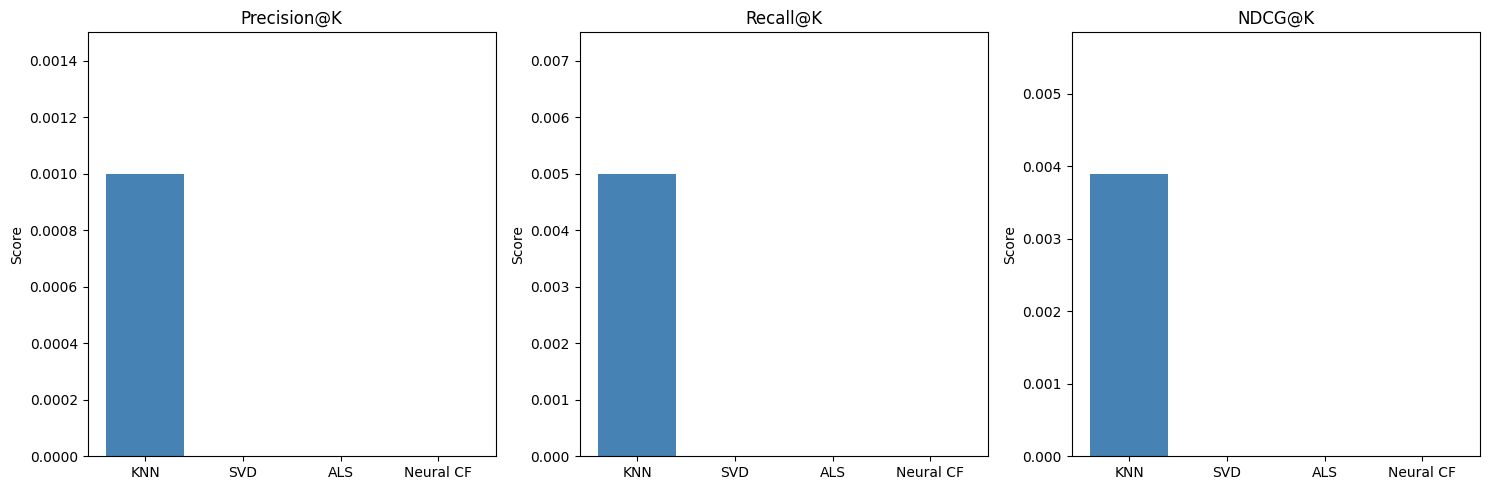

In [42]:
import matplotlib.pyplot as plt
import numpy as np

models = list(results.keys())
metrics = ['Precision@K', 'Recall@K', 'NDCG@K']

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, metric in enumerate(metrics):
    values = [results[m][metric] for m in models]
    axes[i].bar(models, values, color=['steelblue', 'orange', 'green', 'red'])
    axes[i].set_title(metric)
    axes[i].set_ylabel('Score')
    axes[i].set_ylim(0, max(values) * 1.5 if max(values) > 0 else 0.01)

plt.tight_layout()
plt.savefig('docs/figures/model_comparison.png', dpi=150)
plt.show()

In [ ]:
processed_path = config['paths']['processed_data']

# KNN
joblib.dump(knn_model, processed_path + 'knn_model.pkl')

# SVD
joblib.dump(svd_model, processed_path + 'svd_model.pkl')
joblib.dump(user_factors, processed_path + 'user_factors.pkl')
joblib.dump(item_factors, processed_path + 'item_factors.pkl')

# ALS
joblib.dump(als_model, processed_path + 'als_model.pkl')

# Neural CF
torch.save(model.state_dict(), processed_path + 'neural_cf.pth')

print("✅ All models saved!")

✅ All models saved!


In [36]:
print(f"n_users: {n_users}")
print(f"n_items: {n_items}")
print(f"max user_id in train: {train_df['user_id'].max()}")
print(f"max asin in train:    {train_df['asin'].max()}")

n_users: 14789
n_items: 50723
max user_id in train: 14788
max asin in train:    50722
